(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_798/1292035632.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day') ['total_bill'].mean()


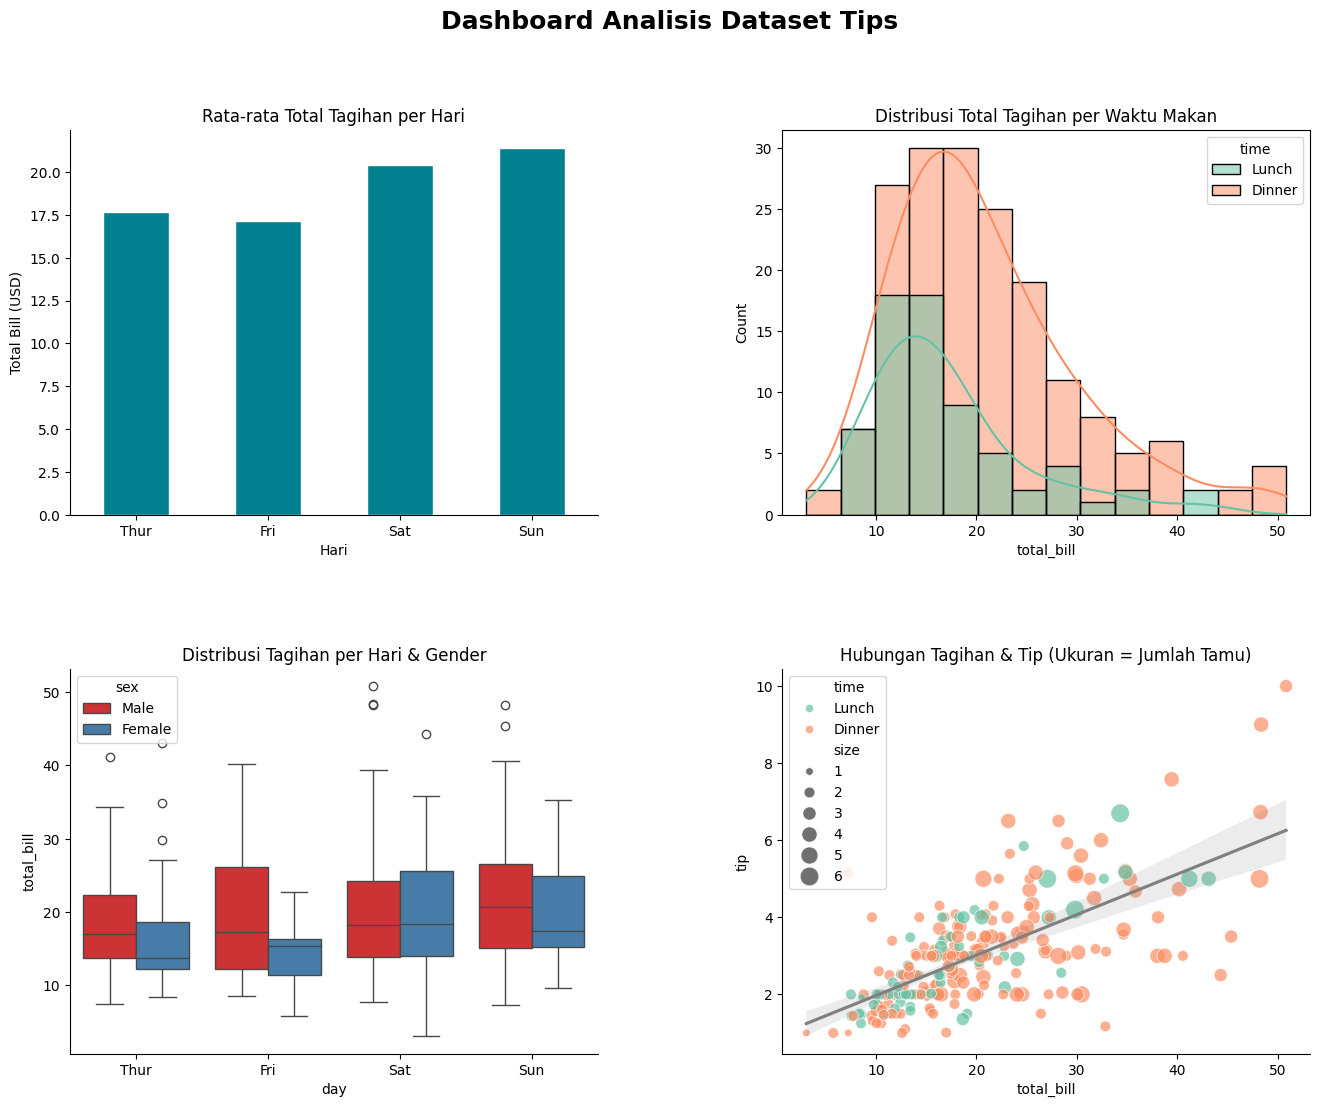

Dashboard tersimpan sebagai dashboard tips.png


In [ ]:
# Nama: Berliana Setyani | NIM: 240401070504 | Kelas: IF-401

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# Load & Inspect Dataset
df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

# Setup Figure Layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1: BAR CHART
# What? Grafik batang menunjukkan rata-rata tagihan harian berkisar antara  17.15(Jumat) hingga tertinggi 21.41 (Minggu). Akhir pekan (Sabtu-Minggu) secara konsisten menghasilkan rata-rata tagihan yang lebih besar dibandingkan hari kerja.
# So what? Hal ini mengindikasikan bahwa pelanggan cenderung berbelanja lebih banyak untuk makan di akhir pekan, kemungkinan karena durasi makan yang lebih lama atau grup yang lebih besar. Selisih sekitar $4 antara hari Jumat dan Minggu cukup signifikan untuk perencanaan pendapatan.
# Now what? Manajemen dapat mempertimbangkan strategi upselling khusus di hari kerja untuk meningkatkan rata-rata tagihan agar mendekati angka akhir pekan.
avg_by_day = df.groupby('day') ['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)


# Grafik 2: HISTOGRAM + KDE
# What? Histogram menunjukkan distribusi tagihan makan malam (Dinner) memiliki jangkauan yang lebih luas hingga mencapai $50.81, sementara makan siang (Lunch) lebih terkonsentrasi di angka yang lebih rendah. Garis KDE mengonfirmasi bahwa puncak distribusi makan malam bergeser ke kanan dibandingkan makan siang.
# So what? Makan malam adalah penyumbang pendapatan utama dengan volume transaksi tinggi dan nilai transaksi yang lebih besar. Data menunjukkan bahwa peluang mendapatkan tagihan di atas $30 hampir seluruhnya terjadi pada waktu makan malam.
# Now what? Fokuskan staf paling berpengalaman pada shift makan malam dan pertimbangkan menu set makan siang yang lebih cepat saji untuk meningkatkan perputaran meja.
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax1.spines[['top', 'right']].set_visible(False)


# Grafik 3: BOXPLOT
# What? Boxplot mengungkapkan bahwa pria cenderung memiliki variasi pengeluaran yang lebih lebar dan nilai outlier yang lebih tinggi (mencapai >$50) dibandingkan wanita, terutama di hari Sabtu dan Minggu. Median tagihan pria juga seringkali sedikit lebih tinggi daripada wanita di sebagian besar hari.
# So what? Segmentasi pelanggan berdasarkan gender menunjukkan profil risiko dan potensi belanja yang berbeda. Pria lebih sering menjadi penggerak tagihan bernilai tinggi (high-spenders) di restoran ini.
# Now what? Perlu dieksplorasi apakah tingginya tagihan pria berkorelasi dengan ukuran grup yang mereka bawa atau preferensi menu tertentu.
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', ax=ax3, palette='Set1')
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)


# Grafik 4: SCATTER PLOT
# What? Scatter plot menunjukkan korelasi positif yang kuat antara total tagihan dan jumlah tip, dengan nilai tip maksimum sebesar $10.00. Ukuran titik menunjukkan bahwa grup yang lebih besar (hingga 6 orang) cenderung menghasilkan tagihan yang lebih besar pula.
# So what? Garis regresi membuktikan bahwa secara rata-rata, tip meningkat seiring bertambahnya tagihan. Namun, terdapat beberapa kasus di mana tagihan tinggi tidak selalu menghasilkan tip yang proporsional (titik-titik di bawah garis regresi).
# Now what? Analisis lebih lanjut diperlukan untuk melihat apakah kualitas layanan pada meja besar mempengaruhi persentase tip, atau apakah ada batasan psikologis pelanggan dalam memberikan tip maksimal.
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30, 180), ax=ax4, palette='Set2', alpha=0.7)
sns.regplot(data=df, x='total_bill', y='tip', ax=ax4, scatter=False, color='gray')
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

# Ekspor
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard tips.png')

# Kesimpulan
# Apa yang dipelajari: Mempelajari cara memuat dataset (menggunakan sns.load_dataset), melihat bentuk (.shape), tipe data (.dtypes), dan statistik deskriptif dasar (.describe()) dari sebuah DataFrame Pandas. Menggunakan groupby() untuk mengagregasi data dan menghitung rata-rata. Menggunakan Matplotlib untuk membuat tata letak figur (plt.figure, gridspec.GridSpec, fig.add_subplot) yang kompleks dengan beberapa subplot. Menggunakan Seaborn (sns.histplot, sns.boxplot, sns.scatterplot, sns.regplot) dan Matplotlib (.plot(kind='bar'), .set_title, .set_xlabel, .set_ylabel) untuk membuat berbagai jenis grafik (bar chart, histogram, box plot, scatter plot) untuk eksplorasi data. Mengatur judul plot, label sumbu, warna, rotasi label, dan menyembunyikan 'spines' untuk tampilan yang lebih bersih. Cara menambahkan kde (Kernel Density Estimate) ke histogram dan menggunakan hue serta size dalam scatter plot untuk menampilkan dimensi data tambahan. Menggunakan plt.savefig() untuk menyimpan plot sebagai file gambar (.png) dan plt.show() untuk menampilkan plot.
# Temuan Utama: Akhir pekan dan waktu makan malam adalah periode paling menguntungkan, dengan rata-rata tagihan tertinggi. Pria berpotensi menjadi target untuk strategi upselling atau menu premium karena kecenderungan mereka untuk pengeluaran yang lebih tinggi. Ada korelasi positif yang kuat antara total tagihan dan jumlah tip, dan ukuran grup juga memengaruhi besarnya tagihan.